# RL Experiment Plots

Visualize training metrics from RL experiments across three settings:
- `real_world`
- `simulation`
- `simulation_with_real_world_input`

Metrics: `ep_len_mean`, `ep_rew_mean`, `top_score`

In [18]:
from tbparse import SummaryReader
import pandas as pd
import os

# log_dir = "/home/wsl/mygit/rwrl_backup/runs/AtlantisNoFrameskip-v4/DQN_1/events.out.tfevents.1773319891.A512025.293052.0"
# output_dir = "/home/wsl/mygit/rwrl_backup/runs/AtlantisNoFrameskip-v4/DQN_1/"
# log_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\tensorboard\\breakout_20260401_000009\\events.out.tfevents.1774962009.b3611ff33acb.2909.0"
# output_dir = "C:\\GitHub\\data_and_plot\\ep_rew_mean\\wgzqrmn3\\"
# log_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\tensorboard\\breakout_20260529_224645\\events.out.tfevents.1780058805.b3611ff33acb.7836.0"
# output_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\"
# log_dir = "C:\\GitHub\\data_and_plot\\10_66_28_74\\tensorboard\\breakout_20260424_231658\\events.out.tfevents.1777036618.f9131d64a981.2853.0"
# output_dir = "C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\"
# log_dir = "C:\\GitHub\\data_and_plot\\simulation_best_model\\tensorboard\\BreakoutNoFrameskip-v4\\DQN_1\\events.out.tfevents.1781071073.A512025.1083587.0"
# output_dir = "C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\"
log_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\tensorboard\\breakout_20260718_151806\\events.out.tfevents.1785060462.c718ab376e4a.30.0"
# log_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\tensorboard\\breakout_20260718_151806\\events.out.tfevents.1784351886.afd547a9d119.1763.0"
output_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260718\\second\\"

os.makedirs(output_dir, exist_ok=True)

reader = SummaryReader(log_dir, extra_columns={'wall_time'})

# Export scalars
df = reader.scalars
df.to_csv(os.path.join(output_dir, "scalars.csv"), index=False)

for tag, group in df.groupby("tag"):
    safe_tag = tag.split("/", 1)[-1]
    print(f"Exporting tag: {tag} to {safe_tag}.csv with columns: {group.columns.tolist()}")

    # Drop tag and dir_name columns if they exist
    group = group.drop(columns=["tag"], errors="ignore")

    # If wall_time exists, move it to the front
    if "wall_time" in group.columns:
        cols = ["wall_time"] + [c for c in group.columns if c != "wall_time"]
        group = group[cols]
    # Rename wall_time → "Wall time"
    group = group.rename(columns={"wall_time": "Wall time"})
    group.columns = [col.capitalize() for col in group.columns]

    out_path = os.path.join(output_dir, f"{safe_tag}.csv")
    group.to_csv(out_path, index=False)

# # Export histograms
# if reader.histograms is not None:
#     reader.histograms.to_csv(os.path.join(output_dir, "histograms.csv"), index=False)

# # Export tensors
# if reader.tensors is not None:
#     reader.tensors.to_csv(os.path.join(output_dir, "tensors.csv"), index=False)

# # Export text
# if reader.text is not None:
#     reader.text.to_csv(os.path.join(output_dir, "text.csv"), index=False)

# # Export images metadata (not the raw images)
# if reader.images is not None:
#     reader.images.to_csv(os.path.join(output_dir, "images.csv"), index=False)

print("All TensorBoard data exported to CSV.")

Exporting tag: rollout/ep_len_mean to ep_len_mean.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: rollout/ep_rew_mean to ep_rew_mean.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: rollout/exploration_rate to exploration_rate.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: rollout/top_score to top_score.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: time/episodes to episodes.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: time/fps to fps.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: time/total_steps to total_steps.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: train/loss to loss.csv with columns: ['step', 'tag', 'value', 'wall_time']
All TensorBoard data exported to CSV.


In [19]:
import sys
from pathlib import Path
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = Path("..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import plot_functions
importlib.reload(plot_functions)
from plot_functions import plot_learning_curves

import style
importlib.reload(style)
from style import MatplotlibStyle

mpl_style = MatplotlibStyle()
mpl_style.apply()

In [20]:
def load_hns_scores(files_dict: dict, random_score: float, human_score: float) -> dict:
    """
    Load episode-score arrays from .npz files and convert to Human Normalized Score.

    Args:
        files_dict:   dict mapping label -> path to .npz file containing key 'array'.
        random_score: random-agent baseline score for the game.
        human_score:  human reference score for the game.

    Returns:
        dict mapping label -> 1-D numpy array of HNS values.
    """
    hns = {}
    for label, path in files_dict.items():
        raw = np.load(path)['array'].astype(float)
        hns[label] = (raw - random_score) / (human_score - random_score)
    return hns


In [21]:
from scipy.stats import bootstrap as _scipy_bootstrap


# ── Helper statistics ────────────────────────────────────────────────────────
def _iqm(x):
    """Interquartile Mean: mean of scores in the [Q25, Q75] range."""
    q25, q75 = np.percentile(x, [25, 75])
    return np.mean(x[(x >= q25) & (x <= q75)])


def _bootstrap_ci(data, stat_fn, n_resamples=10_000, ci=0.95, seed=0):
    """Return (point_estimate, ci_low, ci_high) via percentile bootstrap."""
    result = _scipy_bootstrap(
        (data,), stat_fn,
        n_resamples=n_resamples,
        confidence_level=ci,
        method='percentile',
        random_state=seed,
    )
    return stat_fn(data), result.confidence_interval.low, result.confidence_interval.high


# ── Plotting function ────────────────────────────────────────────────────────
def plot_interval_estimates(
    hns_scores,
    metric='Median',
    system_order=None,
    colours=None,
    figsize=(6.0, 2.6),
    bar_height=0.45,
    n_resamples=10_000,
    ci=0.95,
    save_path=None,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
):
    """
    Plot a single interval-estimate bar chart for one statistic (Median / IQM / Mean).
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        hns_scores:    dict mapping system label -> 1-D numpy array of HNS values.
        metric:        statistic to display: 'Median', 'IQM', or 'Mean'.
        system_order:  list of labels in display order (top to bottom).
                       Defaults to hns_scores.keys().
        colours:       dict mapping label -> colour string. Defaults to built-in palette.
        figsize:       figure size (width, height) in inches.
        bar_height:    height of each CI bar (0–1).
        n_resamples:   bootstrap resamples for CI estimation.
        ci:            confidence level, e.g. 0.95 for 95% CI.
        save_path:     if given, saves figure as <save_path>.pdf.
        dpi:           resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: x-axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    _STAT_FNS = {'Median': np.median, 'IQM': _iqm, 'Mean': np.mean}
    if metric not in _STAT_FNS:
        raise ValueError(f"metric must be one of {list(_STAT_FNS.keys())}, got '{metric}'")
    stat_fn = _STAT_FNS[metric]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  13)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 11)

    _DEFAULT_COLOURS = {
        'simulation':        '#2BAAAB',
        'real world input':  '#E8A817',
        'real world system': '#3A88C5',
    }
    if colours is None:
        colours = _DEFAULT_COLOURS
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(hns_scores.keys()))
        colours = dict(zip(hns_scores.keys(), color_palette))
    if system_order is None:
        system_order = list(hns_scores.keys())

    fig, ax = plt.subplots(figsize=figsize)

    for yi, label in enumerate(system_order):
        data = hns_scores[label]
        pt, lo, hi = _bootstrap_ci(data, stat_fn, n_resamples=n_resamples, ci=ci)
        color = colours.get(label, 'steelblue')

        ax.barh(yi, hi - lo, left=lo, height=bar_height,
                color=color, alpha=0.85, linewidth=0)
        ax.plot([pt, pt], [yi - bar_height / 2, yi + bar_height / 2],
                color='black', linewidth=1.8, solid_capstyle='round')

    ax.set_yticks(range(len(system_order)))
    ax.set_yticklabels(system_order, fontsize=_tick_fs)
    ax.set_xlabel('Human Normalized Score', fontsize=_label_fs)
    ax.set_title(metric, fontsize=_title_fs, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=_tick_fs)
    ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

    if save_path:
        fig.savefig(f'{save_path}.png', dpi=dpi, bbox_inches='tight')
    fig.tight_layout()
    plt.show()


## Data Processing to find the best model

In [40]:
import time
import numpy as np

from evaluation.atari_data import get_human_normalized_score, get_env_id
from evaluation import library as rly
from evaluation import metrics
from evaluation import plot_utils

import tkinter as tk

import os

import gymnasium as gym

import argparse
from distutils.util import strtobool

import ale_py
gym.register_envs(ale_py)
# gym.pprint_registry()


In [41]:
gym_id = "BreakoutNoFrameskip-v4"

In [42]:
env_id = get_env_id(gym_id)
print(f"env_id: {env_id}")

env_id: breakout


In [539]:
files = ['C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260611_sim_best_model\\breakout-data-dqn-model-random_0.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260611_sim_best_model\\breakout-data-dqn-model-best-model_1.npz']

labels = ['0', '1']

In [44]:
f = 0

for file_path in files:
    
    f += 1
    
    # Load the existing data from the .npz file
    loaded_data = np.load(file_path)
    
    # Retrieve the existing array and datetime
    raw_scores = loaded_data['array']
    existing_array = np.array([get_human_normalized_score(env_id, score) for score in raw_scores])
    if len(existing_array) == 101:
        existing_array = existing_array[:-1]
        # existing_array = existing_array[1:]
    # print(f"{file_path} Existing array: {existing_array}")
    csvfile = file_path.split('/')[-1].replace('.npz', '.csv')
    np.savetxt(csvfile, existing_array.reshape(-1, 1), delimiter=",")

    min_score = existing_array.min()
    max_score = existing_array.max()
    median = np.median(existing_array)
    mean = np.mean(existing_array)
    
    print("min: " + str(min_score) + " max: " + str(max_score) + " median: " + str(median) + " mean: " + str(mean))

    if f == 1:
        array_for_dict = existing_array
    else:
        array_for_dict = np.vstack((array_for_dict, existing_array))

min: -0.059027777777777776 max: 0.2881944444444445 median: 0.010416666666666668 mean: 0.0017361111111111117
min: -0.059027777777777776 max: 0.11458333333333333 median: 0.010416666666666668 mean: 0.014930555555555558


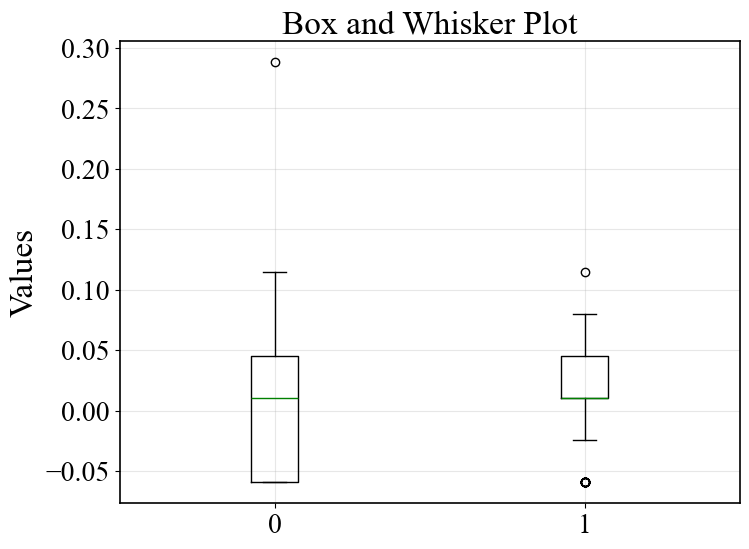

In [45]:
plt.figure(figsize=(8, 6))
bp = plt.boxplot(list(array_for_dict), tick_labels=labels)
plt.ylabel('Values')
plt.title('Box and Whisker Plot')
plt.grid(True, alpha=0.3)
plt.draw()
 
plt.pause(0.1)
plt.show()

In [46]:
hns_dict = {}

for i in range(min(len(labels), array_for_dict.shape[0])):
    # The evaluation library expects 2D arrays: [num_runs, num_tasks]
    # array_for_dict[i] is 1D (101 scores from 101 test episodes)
    # We need to reshape it to 2D: [101 runs, 1 task] for single-task evaluation
    # print(f"Original shape of array_for_dict[{i}]: {array_for_dict[i].shape}")
    scores_2d = np.array(array_for_dict[i]).reshape(-1, 1)  # Convert 1D to 2D
    # print(f"Reshaped scores_2d for {labels[i]}: {scores_2d.shape}")
    # scores_2d = np.array(array_for_dict[i]).reshape(1, -1)  # Convert 1D to 2D
    hns_dict[labels[i]] = scores_2d
    # hns_dict[labels[i]] = array_for_dict[i]

# for key, value in hns_dict.items():
#     print(f"{key}: ")
#     print(f"{value}")

aggregate_scores 0: 
[ 0.01041667 -0.00416667  0.00173611  0.99826389]
aggregate_scores 1: 
[0.01041667 0.02083333 0.01493056 0.98506944]
aggregate_score_cis 0: 
[[-0.02430556 -0.01666667 -0.00868056  0.98715278]
 [ 0.01041667  0.00763889  0.01284722  1.00868056]]
aggregate_score_cis 1: 
[[0.01041667 0.01319444 0.00659722 0.97708333]
 [0.02777778 0.02777778 0.02291667 0.99340278]]
***** Available algorithms for plotting:  ['0', '1']


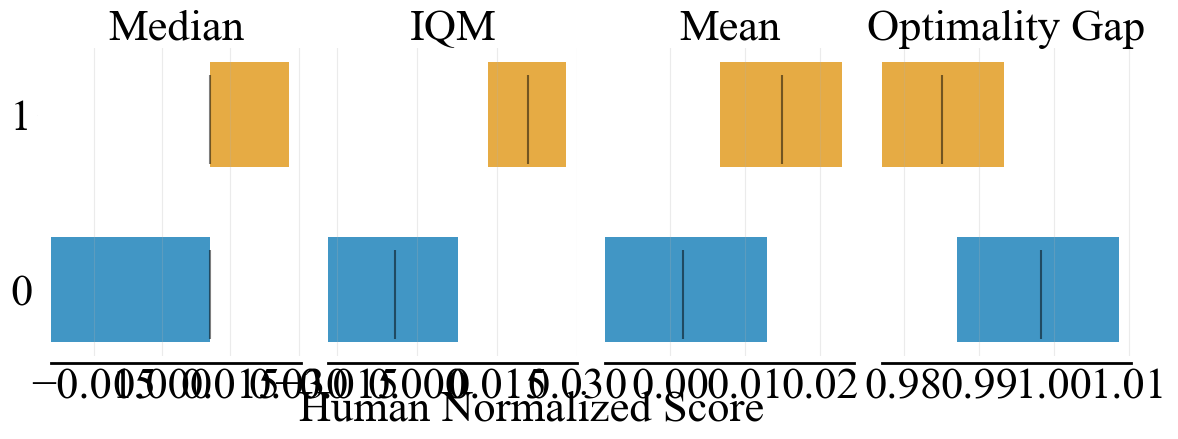

In [47]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_median(x),
    metrics.aggregate_iqm(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_optimality_gap(x)])
    
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig2, ax2 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=available_algorithms,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig2.set_size_inches(12, 4)

plt.figure(fig2.number)

fig2.savefig("hns_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

In [48]:
# files = ['C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260611_sim_best_model\\breakout-data-dqn-model-random_0.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260611_sim_best_model\\breakout-data-dqn-model-best-model_1.npz']

files = ['C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_sim_best_model\\breakout-data-dqn-model-_huggingface_0.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_sim_best_model\\breakout-data-dqn-model-_huggingface_1.npz']

labels = ['0', '1']

In [49]:
f = 0

for file_path in files:
    
    f += 1
    
    # Load the existing data from the .npz file
    loaded_data = np.load(file_path)
    
    # Retrieve the existing array and datetime
    raw_scores = loaded_data['array']
    existing_array = np.array([get_human_normalized_score(env_id, score) for score in raw_scores])
    if len(existing_array) == 101:
        existing_array = existing_array[:-1]
        # existing_array = existing_array[1:]
    # print(f"{file_path} Existing array: {existing_array}")
    csvfile = file_path.split('/')[-1].replace('.npz', '.csv')
    np.savetxt(csvfile, existing_array.reshape(-1, 1), delimiter=",")

    min_score = existing_array.min()
    max_score = existing_array.max()
    median = np.median(existing_array)
    mean = np.mean(existing_array)
    
    print("min: " + str(min_score) + " max: " + str(max_score) + " median: " + str(median) + " mean: " + str(mean))

    if f == 1:
        array_for_dict = existing_array
    else:
        array_for_dict = np.vstack((array_for_dict, existing_array))

min: -0.059027777777777776 max: 0.2881944444444445 median: 0.010416666666666668 mean: 0.0017361111111111117
min: -0.059027777777777776 max: 0.11458333333333333 median: 0.010416666666666668 mean: 0.014930555555555558


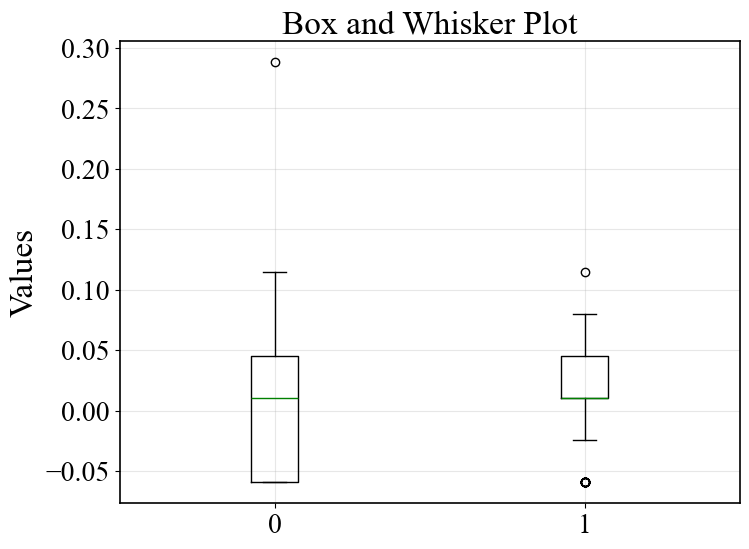

In [50]:
plt.figure(figsize=(8, 6))
bp = plt.boxplot(list(array_for_dict), tick_labels=labels)
plt.ylabel('Values')
plt.title('Box and Whisker Plot')
plt.grid(True, alpha=0.3)
plt.draw()
 
plt.pause(0.1)
plt.show()

In [51]:
hns_dict = {}

for i in range(min(len(labels), array_for_dict.shape[0])):
    # The evaluation library expects 2D arrays: [num_runs, num_tasks]
    # array_for_dict[i] is 1D (101 scores from 101 test episodes)
    # We need to reshape it to 2D: [101 runs, 1 task] for single-task evaluation
    # print(f"Original shape of array_for_dict[{i}]: {array_for_dict[i].shape}")
    scores_2d = np.array(array_for_dict[i]).reshape(-1, 1)  # Convert 1D to 2D
    # print(f"Reshaped scores_2d for {labels[i]}: {scores_2d.shape}")
    # scores_2d = np.array(array_for_dict[i]).reshape(1, -1)  # Convert 1D to 2D
    hns_dict[labels[i]] = scores_2d
    # hns_dict[labels[i]] = array_for_dict[i]

# for key, value in hns_dict.items():
#     print(f"{key}: ")
#     print(f"{value}")

aggregate_scores 0: 
[ 0.01041667 -0.00416667  0.00173611  0.99826389]
aggregate_scores 1: 
[0.01041667 0.02083333 0.01493056 0.98506944]
aggregate_score_cis 0: 
[[-0.02430556 -0.01666667 -0.00868056  0.98680556]
 [ 0.01041667  0.00763889  0.01319444  1.00868056]]
aggregate_score_cis 1: 
[[0.01041667 0.01319444 0.00659722 0.97708333]
 [0.02777778 0.02777778 0.02291667 0.99340278]]
***** Available algorithms for plotting:  ['0', '1']


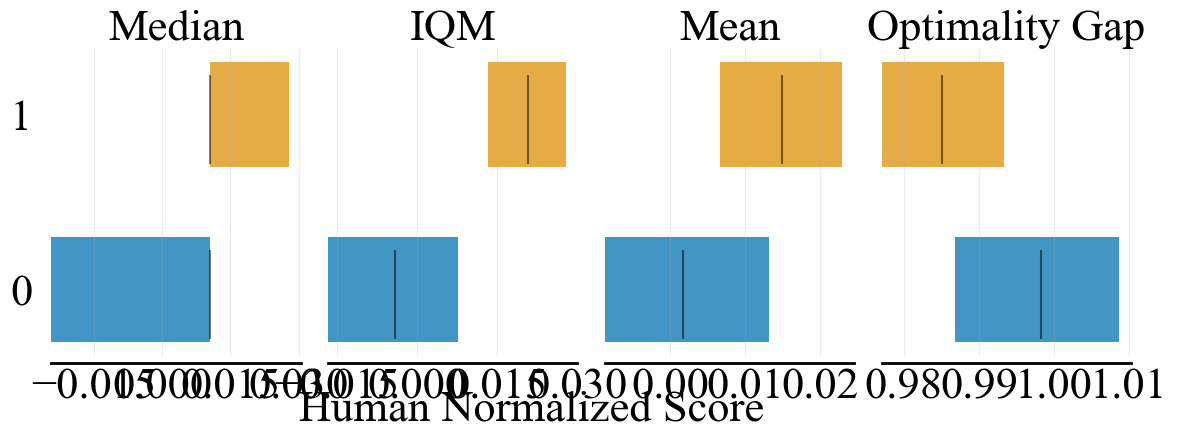

In [52]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_median(x),
    metrics.aggregate_iqm(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_optimality_gap(x)])
    
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig2, ax2 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=available_algorithms,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig2.set_size_inches(12, 4)

plt.figure(fig2.number)

fig2.savefig("hns_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

## Environment Change Impact

In [87]:
# files = ['C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-0_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-1_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-2_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-3_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-4_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-5_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-6_000_000.npz',
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-7_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-8_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-9_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-10_000_000.npz']

files = ['C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_5pixels_up\\breakout-data-dqn-model-0_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_5pixels_up\\breakout-data-dqn-model-1_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_5pixels_up\\breakout-data-dqn-model-2_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_5pixels_up\\breakout-data-dqn-model-3_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_5pixels_up\\breakout-data-dqn-model-4_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_5pixels_up\\breakout-data-dqn-model-5_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_5pixels_up\\breakout-data-dqn-model-6_000_000.npz',
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_5pixels_up\\breakout-data-dqn-model-7_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_5pixels_up\\breakout-data-dqn-model-8_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_5pixels_up\\breakout-data-dqn-model-9_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260810_5pixels_up\\breakout-data-dqn-model-10_000_000.npz']

labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

In [88]:
f = 0

for file_path in files:
    
    f += 1
    
    # Load the existing data from the .npz file
    loaded_data = np.load(file_path)
    
    # Retrieve the existing array and datetime
    raw_scores = loaded_data['array']
    existing_array = np.array([get_human_normalized_score(env_id, score) for score in raw_scores])
    if len(existing_array) == 101:
        existing_array = existing_array[:-1]
        # existing_array = existing_array[1:]
    # print(f"{file_path} Existing array: {existing_array}")
    csvfile = file_path.split('/')[-1].replace('.npz', '.csv')
    np.savetxt(csvfile, existing_array.reshape(-1, 1), delimiter=",")

    min_score = existing_array.min()
    max_score = existing_array.max()
    median = np.median(existing_array)
    mean = np.mean(existing_array)
    
    print("min: " + str(min_score) + " max: " + str(max_score) + " median: " + str(median) + " mean: " + str(mean))
    if f == 1:
        array_for_dict = existing_array
    else:
        array_for_dict = np.vstack((array_for_dict, existing_array))


min: -0.059027777777777776 max: 0.11458333333333333 median: -0.024305555555555552 mean: -0.00798611111111111
min: -0.059027777777777776 max: 0.14930555555555555 median: 0.010416666666666668 mean: 0.0125
min: -0.059027777777777776 max: 0.21875 median: 0.010416666666666668 mean: 0.015625000000000003
min: -0.059027777777777776 max: 0.21875 median: -0.024305555555555552 mean: 0.005555555555555556
min: -0.059027777777777776 max: 0.0798611111111111 median: 0.010416666666666668 mean: 0.004513888888888888
min: -0.059027777777777776 max: 0.11458333333333333 median: 0.010416666666666668 mean: 0.007638888888888889
min: -0.059027777777777776 max: 0.04513888888888889 median: -0.059027777777777776 mean: -0.053125
min: -0.059027777777777776 max: 0.18402777777777776 median: -0.024305555555555552 mean: -0.01909722222222222
min: -0.059027777777777776 max: 0.18402777777777776 median: 0.010416666666666668 mean: 0.029166666666666664
min: -0.059027777777777776 max: 0.11458333333333333 median: -0.02430555555

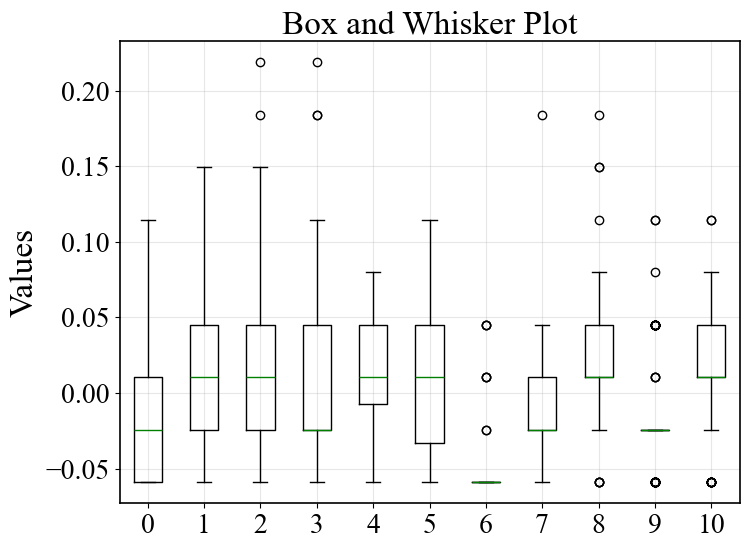

In [89]:
plt.figure(figsize=(8, 6))
bp = plt.boxplot(list(array_for_dict), tick_labels=labels)
plt.ylabel('Values')
plt.title('Box and Whisker Plot')
plt.grid(True, alpha=0.3)
plt.draw()
 
plt.pause(0.1)
plt.show()

In [90]:
hns_dict = {}

for i in range(min(len(labels), array_for_dict.shape[0])):
    # The evaluation library expects 2D arrays: [num_runs, num_tasks]
    # array_for_dict[i] is 1D (101 scores from 101 test episodes)
    # We need to reshape it to 2D: [101 runs, 1 task] for single-task evaluation
    # print(f"Original shape of array_for_dict[{i}]: {array_for_dict[i].shape}")
    scores_2d = np.array(array_for_dict[i]).reshape(-1, 1)  # Convert 1D to 2D
    # print(f"Reshaped scores_2d for {labels[i]}: {scores_2d.shape}")
    # scores_2d = np.array(array_for_dict[i]).reshape(1, -1)  # Convert 1D to 2D
    hns_dict[labels[i]] = scores_2d

aggregate_scores 0: 
[-0.02430556 -0.00902778 -0.00798611  1.00798611]
aggregate_scores 1: 
[0.01041667 0.01805556 0.0125     0.9875    ]
aggregate_scores 2: 
[0.01041667 0.00555556 0.015625   0.984375  ]
aggregate_scores 3: 
[-0.02430556 -0.00416667  0.00555556  0.99444444]
aggregate_scores 4: 
[0.01041667 0.01319444 0.00451389 0.99548611]
aggregate_scores 5: 
[0.01041667 0.01319444 0.00763889 0.99236111]
aggregate_scores 6: 
[-0.05902778 -0.05902778 -0.053125    1.053125  ]
aggregate_scores 7: 
[-0.02430556 -0.02222222 -0.01909722  1.01909722]
aggregate_scores 8: 
[0.01041667 0.02291667 0.02916667 0.97083333]
aggregate_scores 9: 
[-0.02430556 -0.02430556 -0.01805556  1.01805556]
aggregate_scores 10: 
[0.01041667 0.02083333 0.01979167 0.98020833]
aggregate_score_cis 0: 
[[-2.43055556e-02 -2.08333333e-02 -1.63194444e-02  9.99305556e-01]
 [ 1.04166667e-02 -1.38888889e-03  6.94444444e-04  1.01631944e+00]]
aggregate_score_cis 1: 
[[0.01041667 0.00694444 0.00381944 0.97881944]
 [0.01041667

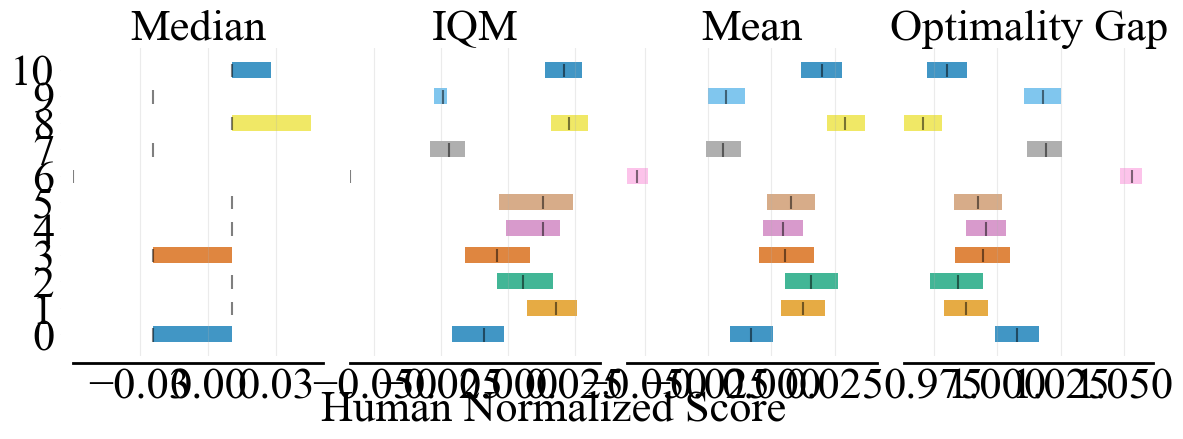

In [91]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_median(x),
    metrics.aggregate_iqm(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_optimality_gap(x)])
    
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig2, ax2 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=available_algorithms,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig2.set_size_inches(12, 4)

plt.figure(fig2.number)

fig2.savefig("hns_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

In [156]:
files = ['C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-0_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-1_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-2_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-3_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-4_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-5_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-6_000_000.npz',
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-7_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-8_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-9_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260612_5pixels_up\\breakout-data-dqn-model-10_000_000.npz']

labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

In [157]:
f = 0

for file_path in files:
    
    f += 1
    
    # Load the existing data from the .npz file
    loaded_data = np.load(file_path)
    
    # Retrieve the existing array and datetime
    raw_scores = loaded_data['array']
    existing_array = np.array([get_human_normalized_score(env_id, score) for score in raw_scores])
    if len(existing_array) == 101:
        existing_array = existing_array[:-1]
        # existing_array = existing_array[1:]
    # print(f"{file_path} Existing array: {existing_array}")
    csvfile = file_path.split('/')[-1].replace('.npz', '.csv')
    np.savetxt(csvfile, existing_array.reshape(-1, 1), delimiter=",")

    min_score = existing_array.min()
    max_score = existing_array.max()
    median = np.median(existing_array)
    mean = np.mean(existing_array)
    
    print("min: " + str(min_score) + " max: " + str(max_score) + " median: " + str(median) + " mean: " + str(mean))

    if f == 1:
        array_for_dict = existing_array
    else:
        array_for_dict = np.vstack((array_for_dict, existing_array))

min: -0.059027777777777776 max: 0.3229166666666667 median: -0.024305555555555552 mean: -0.01076388888888889
min: -0.059027777777777776 max: 0.11458333333333333 median: -0.059027777777777776 mean: -0.0034722222222222238
min: -0.059027777777777776 max: 0.2534722222222222 median: -0.059027777777777776 mean: 0.04097222222222222
min: -0.059027777777777776 max: -0.059027777777777776 median: -0.059027777777777776 mean: -0.059027777777777776
min: -0.059027777777777776 max: 0.2881944444444445 median: -0.059027777777777776 mean: -0.015277777777777777
min: -0.059027777777777776 max: 0.2534722222222222 median: -0.059027777777777776 mean: 0.011805555555555555
min: -0.059027777777777776 max: 0.11458333333333333 median: -0.059027777777777776 mean: -0.010069444444444447
min: -0.059027777777777776 max: -0.024305555555555552 median: -0.059027777777777776 mean: -0.058680555555555555
min: -0.059027777777777776 max: 0.0798611111111111 median: -0.041666666666666664 mean: -0.033680555555555554
min: -0.059027

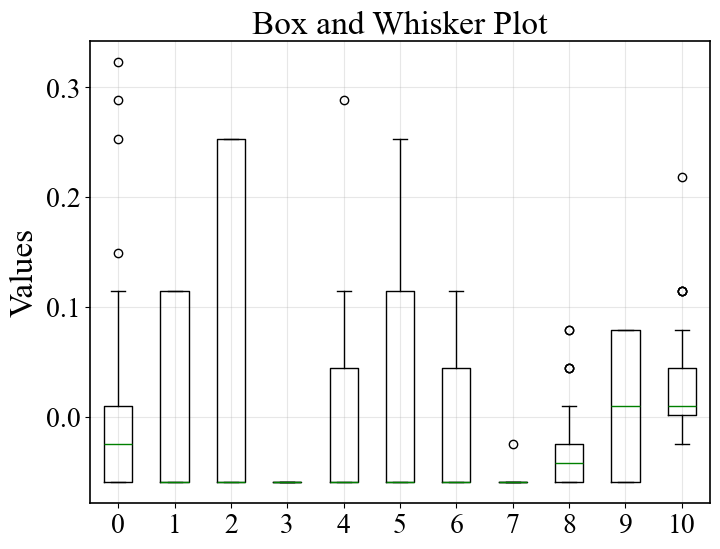

In [158]:
plt.figure(figsize=(8, 6))
bp = plt.boxplot(list(array_for_dict), tick_labels=labels)
plt.ylabel('Values')
plt.title('Box and Whisker Plot')
plt.grid(True, alpha=0.3)
plt.draw()
 
plt.pause(0.1)
plt.show()

In [159]:
hns_dict = {}

for i in range(min(len(labels), array_for_dict.shape[0])):
    # The evaluation library expects 2D arrays: [num_runs, num_tasks]
    # array_for_dict[i] is 1D (101 scores from 101 test episodes)
    # We need to reshape it to 2D: [101 runs, 1 task] for single-task evaluation
    # print(f"Original shape of array_for_dict[{i}]: {array_for_dict[i].shape}")
    scores_2d = np.array(array_for_dict[i]).reshape(-1, 1)  # Convert 1D to 2D
    # print(f"Reshaped scores_2d for {labels[i]}: {scores_2d.shape}")
    # scores_2d = np.array(array_for_dict[i]).reshape(1, -1)  # Convert 1D to 2D
    hns_dict[labels[i]] = scores_2d

aggregate_scores 0: 
[-0.02430556 -0.02986111 -0.01076389  1.01076389]
aggregate_scores 1: 
[-0.05902778 -0.03472222 -0.00347222  1.00347222]
aggregate_scores 2: 
[-0.05902778 -0.01527778  0.04097222  0.95902778]
aggregate_scores 3: 
[-0.05902778 -0.05902778 -0.05902778  1.05902778]
aggregate_scores 4: 
[-0.05902778 -0.04027778 -0.01527778  1.01527778]
aggregate_scores 5: 
[-0.05902778 -0.03472222  0.01180556  0.98819444]
aggregate_scores 6: 
[-0.05902778 -0.0375     -0.01006944  1.01006944]
aggregate_scores 7: 
[-0.05902778 -0.05902778 -0.05868056  1.05868056]
aggregate_scores 8: 
[-0.04166667 -0.04166667 -0.03368056  1.03368056]
aggregate_scores 9: 
[ 0.01041667 -0.00833333  0.00104167  0.99895833]
aggregate_scores 10: 
[0.01041667 0.01736111 0.01909722 0.98090278]
aggregate_score_cis 0: 
[[-0.02430556 -0.04027778 -0.02326389  0.99652778]
 [-0.02430556 -0.01875     0.00347222  1.02326389]]
aggregate_score_cis 1: 
[[-0.05902778 -0.05902778 -0.01909722  0.98784722]
 [-0.05902778 -0.003

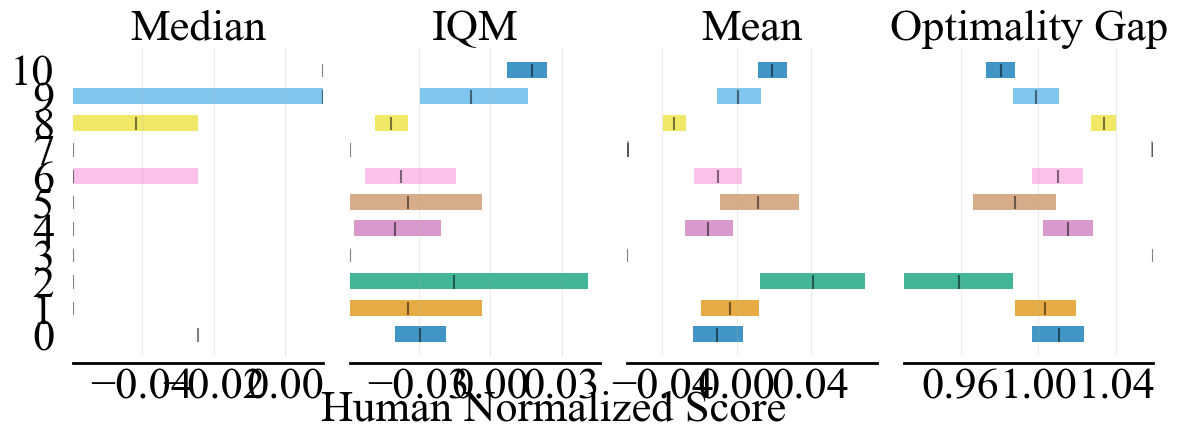

In [160]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_median(x),
    metrics.aggregate_iqm(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_optimality_gap(x)])
    
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig2, ax2 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=available_algorithms,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig2.set_size_inches(12, 4)

plt.figure(fig2.number)

fig2.savefig("hns_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()